In [1]:
# In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)
!python --version

2.19.1
Python 3.12.13


In [2]:
# In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"train data shape: {x_train.shape}")
print(f"label train shape: {y_train.shape}")
print(f"test data shape: {x_test.shape}")
print(f"label test shape: {y_test.shape}")

train data shape: (50000, 32, 32, 3)
label train shape: (50000, 1)
test data shape: (10000, 32, 32, 3)
label test shape: (10000, 1)


In [3]:
# In [3]:
num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)
print(f"label train shape: {y_train.shape}")
print(f"label test shape: {y_test.shape}")

label train shape: (50000, 10)
label test shape: (10000, 10)


In [4]:
# In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_generator_aug():
    data_generator_aug = ImageDataGenerator(rescale=(1/255.0),
                                             rotation_range=35,
                                             width_shift_range=0.3,
                                             height_shift_range=0.3,
                                             fill_mode='nearest',
                                             brightness_range=(0.2,0.8),
                                             shear_range=45.0,
                                             horizontal_flip=True,
                                             vertical_flip=True,
                                             zoom_range=[0.5, 1.5])
    return data_generator_aug

In [5]:
# In [5]:
data_generator_aug = get_generator_aug()
data_generator_aug.fit(x_train)
train_generator_aug = data_generator_aug.flow(x_train, y_train, batch_size=10, shuffle=True)

data_generator_aug_test = get_generator_aug()
data_generator_aug_test.fit(x_test)
test_generator_aug = data_generator_aug_test.flow(x_test, y_test, batch_size=10, shuffle=True)

In [6]:
# In [6]:
data_generator = ImageDataGenerator(rescale=(1/255.0))
data_generator.fit(x_train)
img_generator = data_generator.flow(x_train, y_train, batch_size=10, shuffle=False)

In [7]:
img,label = next(img_generator)
img_aug, label_aug = next(train_generator_aug)

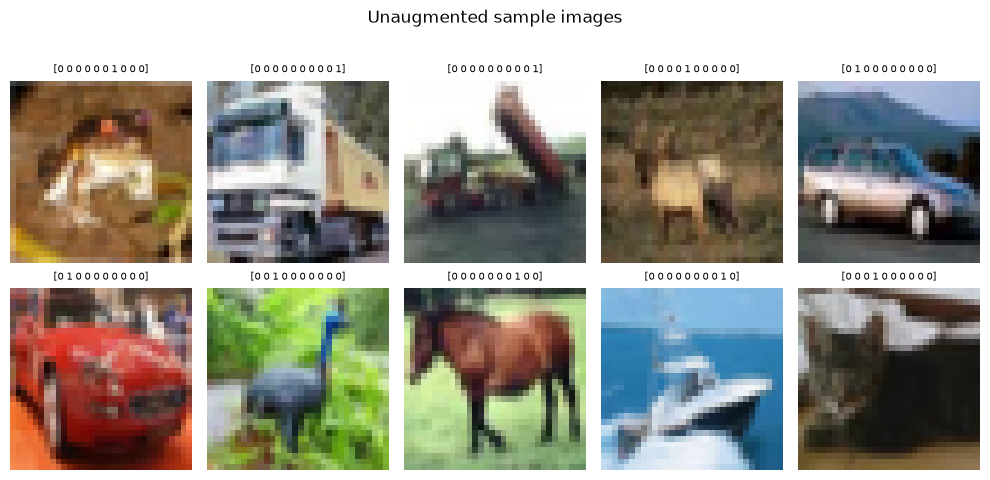

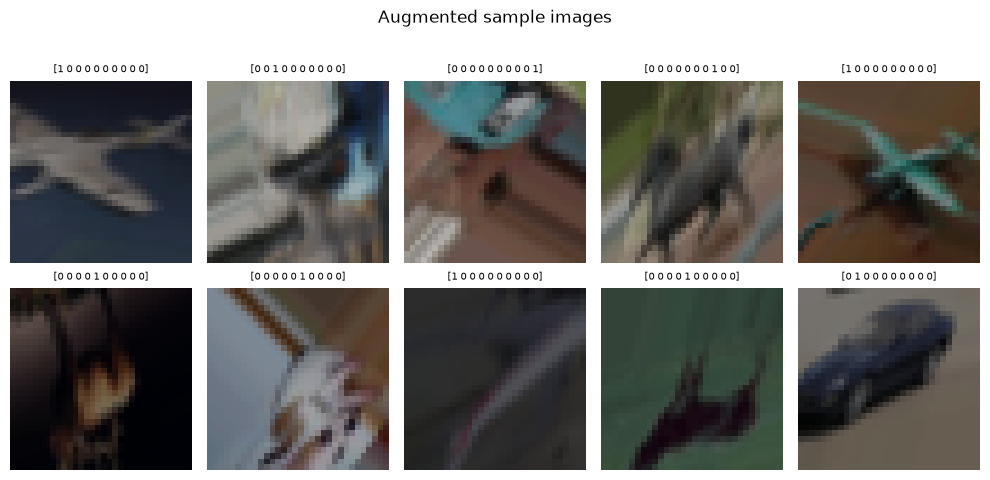

In [11]:
def show_batch(images, labels, title, n_rows=2, n_cols=5):
    plt.figure(figsize=(n_cols * 2, n_rows * 2.4))
    plt.suptitle(title, y=1.02)
    for i in range(min(len(images), n_rows * n_cols)):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(np.clip(images[i], 0, 1))
        plt.title(str(labels[i].astype(int)), fontsize=7)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(img, label, "Unaugmented sample images")
show_batch(img_aug, label_aug, "Augmented sample images")

In [12]:
# In [8]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

In [13]:
# In [9]:
def get_model(input_shape):
    input_layer = Input(input_shape)
    layer1 = Conv2D(32, 8, activation="relu", padding="SAME")(input_layer)
    layer2 = MaxPooling2D((2,2))(layer1)
    layer3 = Conv2D(32, 4, activation="relu", padding="SAME")(layer2)
    layer4 = MaxPooling2D((2,2))(layer3)
    layer5 = Flatten()(layer4)
    layer6 = Dense(16, activation="relu")(layer5)
    output_layer = Dense(10, activation="softmax")(layer6)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
                  loss='categorical_crossentropy', metrics=[tf.keras.metrics.CategoricalAccuracy()])
    return model

In [14]:
# In [ ]:
model = get_model(input_shape = (32,32,3))
model.summary()

2026-09-02 15:13:53.175190: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-02 15:13:53.175360: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-02 15:13:53.175396: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1788342233.176012 3398670 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788342233.176103 3398670 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,546 (216.98 KB)

 Trainable params: 55,546 (216.98 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# In [11]:
from tensorflow.keras.callbacks import EarlyStopping

train_steps_per_epoch = img_generator.n // img_generator.batch_size

In [16]:
# In [ ]:  (still running)
history = model.fit(x_train, y_train, steps_per_epoch=train_steps_per_epoch, validation_data=(x_test, y_test), epochs=20, callbacks=[EarlyStopping('val_categorical_accuracy', patience=5)])

Epoch 1/20


2026-09-02 15:19:12.248690: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 53s 10ms/step - categorical_accuracy: 0.1247 - loss: 15.6404 - val_categorical_accuracy: 0.1623 - val_loss: 12.1416
Epoch 2/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - categorical_accuracy: 0.1523 - loss: 11.6525 - val_categorical_accuracy: 0.1615 - val_loss: 10.0700
Epoch 3/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - categorical_accuracy: 0.1703 - loss: 8.6258 - val_categorical_accuracy: 0.1777 - val_loss: 8.0901
Epoch 4/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - categorical_accuracy: 0.1826 - loss: 7.7902 - val_categorical_accuracy: 0.1572 - val_loss: 10.8012
Epoch 5/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - categorical_accuracy: 0.1807 - loss: 8.2484 - val_categorical_accuracy: 0.1898 - val_loss: 7.4027
Epoch 6/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - categorical_accuracy: 0.1936 - loss: 6.4726 - val_categorical_accuracy: 0.2029 - val_loss: 5.7363
Epoch 7/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - categorical_

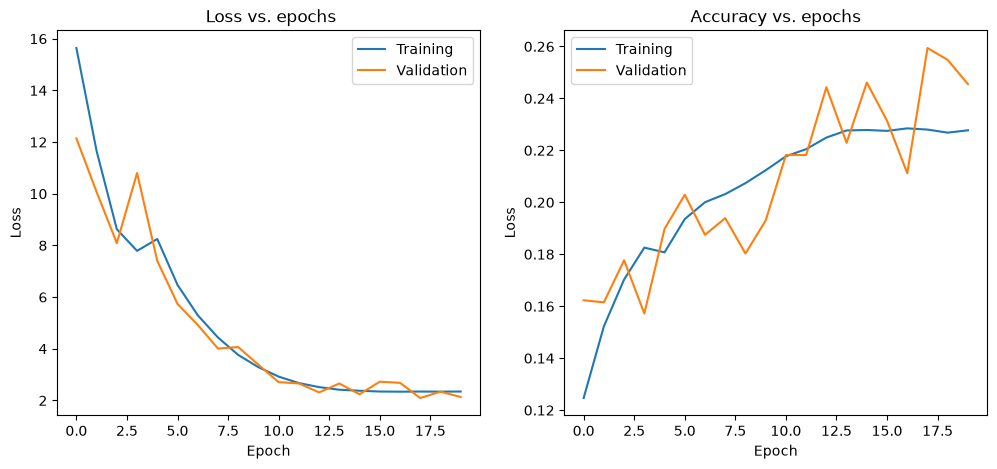

In [17]:
# In [ ]:
fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title(' Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

fig.add_subplot(122)

plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

plt.show()

In [18]:
# In [ ]:
model_aug = get_model(input_shape = (32,32,3))

In [19]:
# In [ ]:
model_aug = get_model(input_shape = (32,32,3))

train_steps_per_epoch = train_generator_aug.n // train_generator_aug.batch_size

history_aug = model_aug.fit(train_generator_aug, steps_per_epoch=train_steps_per_epoch,
                             validation_data=test_generator_aug,
                             epochs=20,
                             callbacks=[EarlyStopping(monitor='val_categorical_accuracy', patience=5)])

Epoch 1/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - categorical_accuracy: 0.1831 - loss: 2.1576 - val_categorical_accuracy: 0.2299 - val_loss: 2.0734
Epoch 2/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - categorical_accuracy: 0.1830 - loss: 2.2201 - val_categorical_accuracy: 0.1820 - val_loss: 2.1922
Epoch 3/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 63s 13ms/step - categorical_accuracy: 0.1950 - loss: 2.2008 - val_categorical_accuracy: 0.2052 - val_loss: 2.1717
Epoch 4/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - categorical_accuracy: 0.1682 - loss: 2.3795 - val_categorical_accuracy: 0.1972 - val_loss: 2.2171
Epoch 5/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - categorical_accuracy: 0.2004 - loss: 2.2300 - val_categorical_accuracy: 0.2127 - val_loss: 2.1705
Epoch 6/20
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - categorical_accuracy: 0.2177 - loss: 2.1583 - val_categorical_accuracy: 0.2151 - val_loss: 2.1681


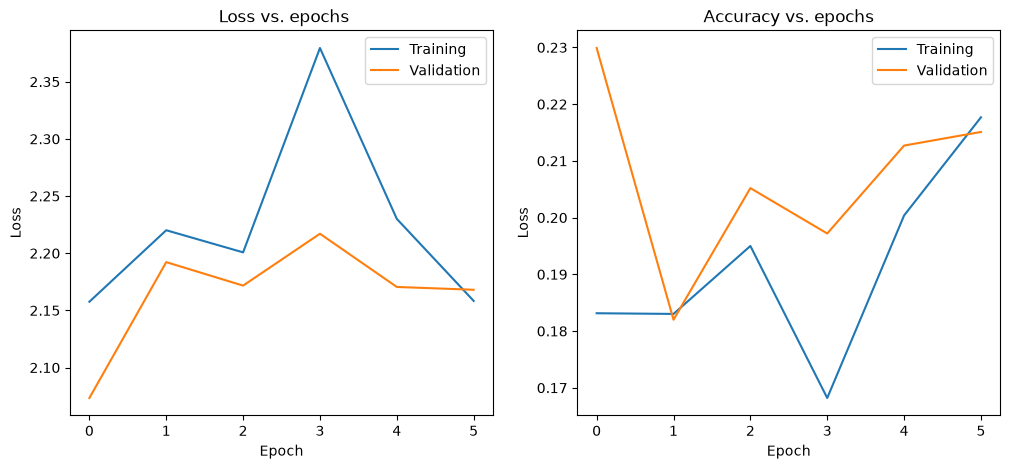

In [20]:
# In [ ]:
fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history_aug.history['loss'])
plt.plot(history_aug.history['val_loss'])
plt.title(' Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

fig.add_subplot(122)

plt.plot(history_aug.history['categorical_accuracy'])
plt.plot(history_aug.history['val_categorical_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

plt.show()

Predictions

In [21]:
predictions = model_aug.predict(test_generator_aug,steps=1)
print(np.round(predictions,2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
[[0.27 0.02 0.11 0.12 0.01 0.02 0.   0.13 0.28 0.04]
 [0.17 0.03 0.2  0.09 0.06 0.04 0.01 0.1  0.16 0.13]
 [0.07 0.01 0.19 0.16 0.1  0.05 0.08 0.3  0.02 0.03]
 [0.08 0.07 0.31 0.1  0.1  0.05 0.13 0.06 0.06 0.03]
 [0.32 0.04 0.19 0.08 0.02 0.03 0.01 0.1  0.19 0.04]
 [0.37 0.04 0.33 0.01 0.   0.01 0.   0.   0.2  0.02]
 [0.04 0.01 0.22 0.09 0.14 0.04 0.26 0.16 0.01 0.02]
 [0.05 0.02 0.09 0.21 0.08 0.07 0.05 0.38 0.02 0.03]
 [0.03 0.01 0.34 0.08 0.11 0.04 0.26 0.11 0.01 0.02]
 [0.03 0.01 0.21 0.13 0.11 0.05 0.21 0.22 0.01 0.02]]
